## Notebook Overview
## Multiclass Classification Methods (ISUP Grades 1–5)

- In this notebook, ISUP grades 1–5 are used to construct a multiclass classification problem, after removing all samples with ISUP grade 0. The remaining grades are relabeled from 1–5 to 0–4 for model compatibility.

- To address class imbalance, SMOTE is applied with predefined target counts, ensuring balanced representation across all ISUP grades before model training.

- The following classification models are evaluated:
    - Logistic Regression
    - K‑Nearest Neighbors (KNN)
    - Random Forest
    - XGBoost
    - Gaussian Process Classifier

- To obtain robust and unbiased performance estimates, we perform nested cross‑validation and specifically:
    - 5‑fold outer Stratified CV for model evaluation
    - 5‑fold inner CV for hyperparameter tuning

- GridSearchCV is used for models with smaller hyperparameter spaces, while RandomizedSearchCV is applied to larger spaces (Random Forest, XGBoost).
For each outer fold:
    - The best hyperparameters are selected
    - The model is retrained on the training folds
    - Predictions, probabilities and uncertainties are computed for the test fold

- Predictive uncertainty is quantified using Shannon entropy, allowing us to assess how confident each model is in its predictions and how uncertainty differs between predicted classes.

- The evaluation metrics used for each model include:
    - Accuracy
    - ROC‑AUC (One‑vs‑Rest)
    - Confusion Matrix
    - Classification Report  
    - Mean predictive uncertainty
    - Per‑class ROC curves

- All classification experiments are carried out using scikit‑learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.base import clone

from imblearn.over_sampling import SMOTE
from scipy.stats import entropy
from tqdm import tqdm
from IPython.display import display

from deep_gp.preprocessing_data import load_data


In [2]:
#  Load original data
data = load_data()

print("=== ORIGINAL DATA ===")
print(data["case_ISUP"].value_counts().sort_index(), "\n")

# remove class 0

df_filtered = data[data["case_ISUP"] != 0].copy()

print("=== AFTER REMOVING CLASS 0 ===")
print(df_filtered["case_ISUP"].value_counts().sort_index(), "\n")


# define multiclass target (0–5)

df_filtered["multiclass_target"] = df_filtered["case_ISUP"]

X_filtered = df_filtered.drop(columns=["case_ISUP", "multiclass_target"])
y_filtered = df_filtered["multiclass_target"]

print("=== BEFORE SMOTE ===")
print(y_filtered.value_counts().sort_index(), "\n")


# apply SMOTE to balance classes 1–5

target_counts = {
    1: 157,   # keep original
    2: 154,   # keep original
    3: 150,
    4: 150,
    5: 150
}

sm = SMOTE(
    sampling_strategy=target_counts,
    k_neighbors=3,
    random_state=42
)

X_smote, y_smote = sm.fit_resample(X_filtered, y_filtered)

# shift labels 1–5 → 0–4 


y_resampled = y_smote - 1
X_resampled = X_smote

print("=== AFTER SMOTE (SHIFTED LABELS 0–4) ===")
print(y_resampled.value_counts().sort_index(), "\n")


print("=== FINAL SHAPES ===")
print("X_resampled:", X_resampled.shape)
print("y_resampled:", y_resampled.shape)


=== ORIGINAL DATA ===
case_ISUP
0    589
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64 

=== AFTER REMOVING CLASS 0 ===
case_ISUP
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64 

=== BEFORE SMOTE ===
multiclass_target
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64 

=== AFTER SMOTE (SHIFTED LABELS 0–4) ===
multiclass_target
0    157
1    154
2    150
3    150
4    150
Name: count, dtype: int64 

=== FINAL SHAPES ===
X_resampled: (761, 109)
y_resampled: (761,)


In [3]:
def evaluate_models_cv_with_tuning(X, y, label):

    print(f"\n=== Feature set: {label} ===")

    n_classes = len(np.unique(y))

    # Base models
    base_models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                solver="saga",
                multi_class="multinomial",
                max_iter=30000,
                tol=1e-4
            ))
        ]),

        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),

        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ]),

        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(
                objective="multi:softprob",
                num_class=n_classes,
                tree_method="hist",
                eval_metric="mlogloss",
                random_state=42
            ))
        ]),

        "Gaussian Process": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GaussianProcessClassifier(
                kernel=C(1.0, (1e-6, 1e6)) *
                       RBF(length_scale=1.0, length_scale_bounds=(1e-6, 1e6)) +
                       WhiteKernel(noise_level=1e-3),
                n_restarts_optimizer=2,
                random_state=42
            ))
        ])
    }

    # hyperparameter grids
    
    param_grids = {
        "Logistic Regression": {
            "clf__C": [0.01, 0.1, 1.0]
        },
        "KNN": {
            "clf__n_neighbors": [3, 5, 7, 9],
            "clf__weights": ["uniform", "distance"]
        },
        "Random Forest": {
            "clf__n_estimators": [200, 300, 400],
            "clf__max_depth": [None, 10, 20],
            "clf__min_samples_split": [2, 5],
            "clf__min_samples_leaf": [1, 2],
            "clf__max_features": ["sqrt", "log2"]
        },
        "XGBoost": {
            "clf__n_estimators": [200, 300],
            "clf__learning_rate": [0.05, 0.1],
            "clf__max_depth": [4, 5, 6],
            "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0]
        },
        "Gaussian Process": {
            "clf__kernel": [
                C(c, (1e-6, 1e6)) * RBF(length_scale=l, length_scale_bounds=(1e-6, 1e6)) +
                WhiteKernel(noise_level=1e-3)
                for c in [0.5, 1.0, 2.0]
                for l in [0.5, 1.0, 2.0]
            ] + [RBF(1.0)],
            "clf__n_restarts_optimizer": [0, 2]
        }
    }

    
    # Outer CV
   
    skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = {}

    for model_name, base_model in base_models.items():

        print(f"\n=== Evaluation: {model_name} ===")

        # Storage for full‑dataset predictions
        y_pred_all = np.zeros(len(y))
        y_prob_all = np.zeros((len(y), n_classes))
        uncertainty_all = np.zeros(len(y))

        best_params_last_fold = None

        # Outer loop
        for train_idx, test_idx in tqdm(
            skf_outer.split(X, y),
            total=skf_outer.get_n_splits(),
            desc=f"Outer CV ({model_name})"
        ):

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Inner CV for tuning
            cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            model_clone = clone(base_model)

            if model_name in ["Random Forest", "XGBoost"]:
                tuner = RandomizedSearchCV(
                    model_clone,
                    param_distributions=param_grids[model_name],
                    n_iter=20,
                    cv=cv_inner,
                    scoring="roc_auc_ovr",
                    n_jobs=-1,
                    random_state=42
                )
            else:
                tuner = GridSearchCV(
                    model_clone,
                    param_grid=param_grids[model_name],
                    cv=cv_inner,
                    scoring="roc_auc_ovr",
                    n_jobs=-1
                )

            tuner.fit(X_train, y_train)
            best_model = tuner.best_estimator_
            best_params_last_fold = tuner.best_params_

            # Fit best model on full training fold
            best_model.fit(X_train, y_train)

            # Predictions
            y_prob = best_model.predict_proba(X_test)
            y_pred = best_model.predict(X_test)

            # Uncertainty (entropy per sample)
            uncertainty = entropy(y_prob, axis=1)

            # Store fold results
            y_pred_all[test_idx] = y_pred
            y_prob_all[test_idx] = y_prob
            uncertainty_all[test_idx] = uncertainty

      
        print("\n>>> Best hyperparameters (last outer fold):", best_params_last_fold)
        print("Accuracy:", accuracy_score(y, y_pred_all))
        print("ROC-AUC (OVR):", roc_auc_score(y, y_prob_all, multi_class="ovr"))
        print("Mean uncertainty:", uncertainty_all.mean())
        print("Confusion matrix:\n", confusion_matrix(y, y_pred_all))
        print(classification_report(y, y_pred_all))

    
        # per-class ROC curves
        
        plt.figure(figsize=(10, 8))

        for class_idx in range(n_classes):
            y_true_bin = (y == class_idx).astype(int)
            y_prob_class = y_prob_all[:, class_idx]

            fpr, tpr, _ = roc_curve(y_true_bin, y_prob_class)
            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr, lw=2, label=f"Class {class_idx} (AUC = {roc_auc:.3f})")

        plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"Per-Class ROC Curves — {model_name}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

        # Store results
        results[model_name] = {
            "accuracy": accuracy_score(y, y_pred_all),
            "roc_auc": roc_auc_score(y, y_prob_all, multi_class="ovr"),
            "mean_uncertainty": uncertainty_all.mean()
        }

    return results



=== Feature set: Multiclass ISUP 1–5 (SMOTE k=3) ===

=== Evaluation: Logistic Regression ===


Outer CV (Logistic Regression):   0%|          | 0/5 [00:00<?, ?it/s]/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will a


>>> Best hyperparameters (last outer fold): {'clf__C': 1.0}
Accuracy: 0.4704336399474376
ROC-AUC (OVR): 0.7425447836874237
Mean uncertainty: 1.2147805781101817
Confusion matrix:
 [[ 57  31  31  22  16]
 [ 55  28  24  29  18]
 [ 29  18  68  17  18]
 [  4  12   3 110  21]
 [ 20  14  10  11  95]]
              precision    recall  f1-score   support

           0       0.35      0.36      0.35       157
           1       0.27      0.18      0.22       154
           2       0.50      0.45      0.48       150
           3       0.58      0.73      0.65       150
           4       0.57      0.63      0.60       150

    accuracy                           0.47       761
   macro avg       0.45      0.47      0.46       761
weighted avg       0.45      0.47      0.46       761



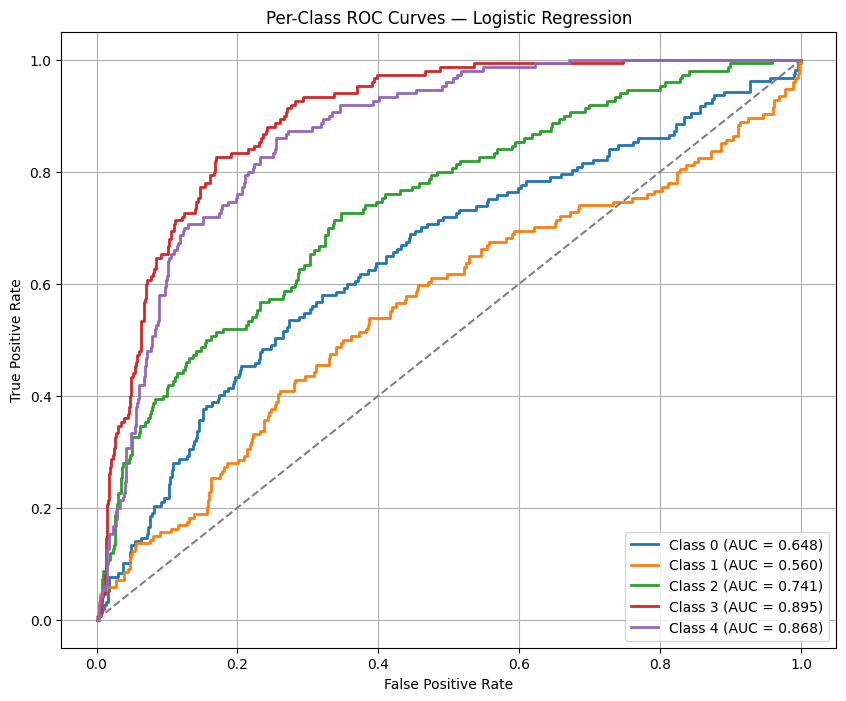


=== Evaluation: KNN ===


Outer CV (KNN): 100%|██████████| 5/5 [00:00<00:00,  6.06it/s]



>>> Best hyperparameters (last outer fold): {'clf__n_neighbors': 7, 'clf__weights': 'distance'}
Accuracy: 0.580814717477004
ROC-AUC (OVR): 0.834489677100384
Mean uncertainty: 0.8186117664266674
Confusion matrix:
 [[ 30  25  37  35  30]
 [ 27  28  31  44  24]
 [ 11   7 101  14  17]
 [  0   0   3 141   6]
 [  2   0   2   4 142]]
              precision    recall  f1-score   support

           0       0.43      0.19      0.26       157
           1       0.47      0.18      0.26       154
           2       0.58      0.67      0.62       150
           3       0.59      0.94      0.73       150
           4       0.65      0.95      0.77       150

    accuracy                           0.58       761
   macro avg       0.54      0.59      0.53       761
weighted avg       0.54      0.58      0.53       761



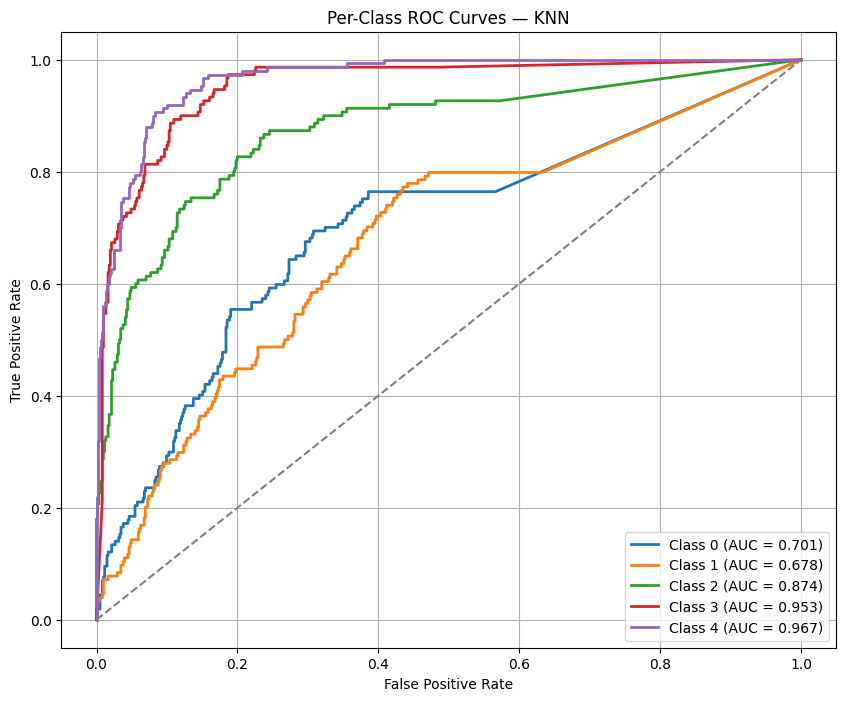


=== Evaluation: Random Forest ===


Outer CV (Random Forest): 100%|██████████| 5/5 [01:03<00:00, 12.79s/it]


>>> Best hyperparameters (last outer fold): {'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 20}
Accuracy: 0.6491458607095927
ROC-AUC (OVR): 0.879439938444051
Mean uncertainty: 1.2233803439721314
Confusion matrix:
 [[ 65  40  21  14  17]
 [ 49  54  19  21  11]
 [ 18  17 106   5   4]
 [  2   4   1 134   9]
 [  5   2   7   1 135]]
              precision    recall  f1-score   support

           0       0.47      0.41      0.44       157
           1       0.46      0.35      0.40       154
           2       0.69      0.71      0.70       150
           3       0.77      0.89      0.82       150
           4       0.77      0.90      0.83       150

    accuracy                           0.65       761
   macro avg       0.63      0.65      0.64       761
weighted avg       0.63      0.65      0.63       761



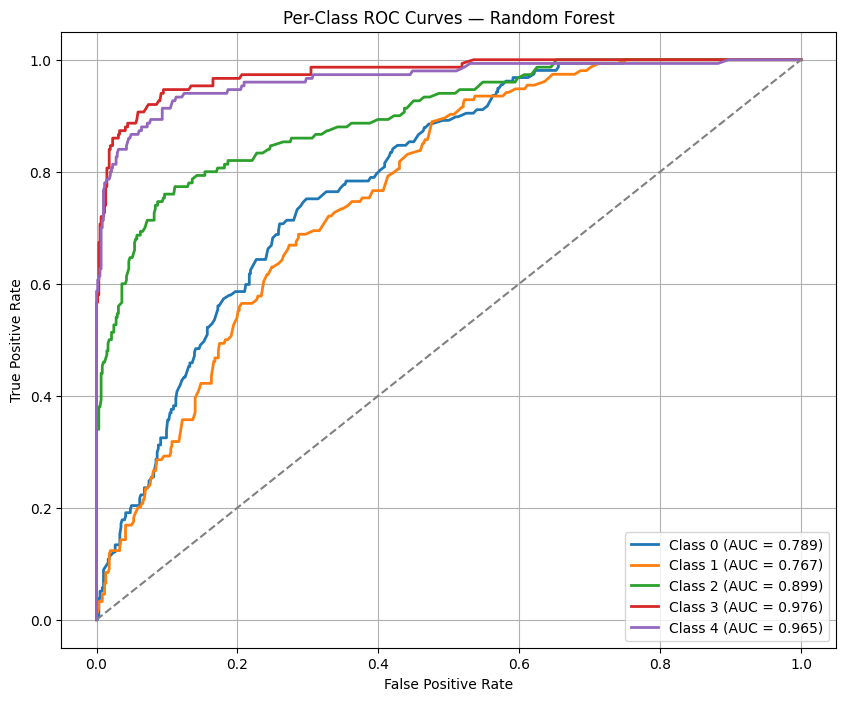


=== Evaluation: XGBoost ===


Outer CV (XGBoost): 100%|██████████| 5/5 [11:19<00:00, 135.99s/it]


>>> Best hyperparameters (last outer fold): {'clf__subsample': 0.8, 'clf__n_estimators': 300, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.8}
Accuracy: 0.6544021024967148
ROC-AUC (OVR): 0.8772582296383005
Mean uncertainty: 0.7942658582538288
Confusion matrix:
 [[ 69  44  26   5  13]
 [ 50  56  19  14  15]
 [ 16  20 108   1   5]
 [  2   4   2 132  10]
 [  6   4   4   3 133]]
              precision    recall  f1-score   support

           0       0.48      0.44      0.46       157
           1       0.44      0.36      0.40       154
           2       0.68      0.72      0.70       150
           3       0.85      0.88      0.87       150
           4       0.76      0.89      0.82       150

    accuracy                           0.65       761
   macro avg       0.64      0.66      0.65       761
weighted avg       0.64      0.65      0.64       761



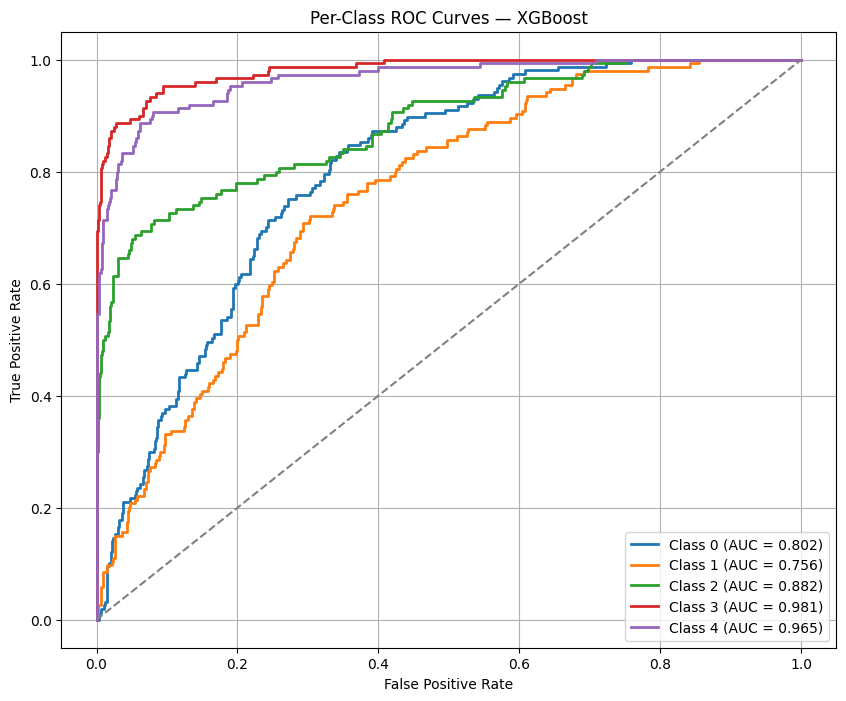


=== Evaluation: Gaussian Process ===


Outer CV (Gaussian Process):   0%|          | 0/5 [00:00<?, ?it/s]/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise


>>> Best hyperparameters (last outer fold): {'clf__kernel': 1**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.001), 'clf__n_restarts_optimizer': 0}
Accuracy: 0.533508541392904
ROC-AUC (OVR): 0.8067550250601411
Mean uncertainty: 1.4401163652833062
Confusion matrix:
 [[ 70   7  36  23  21]
 [ 61   7  36  24  26]
 [ 37   5  97   5   6]
 [ 30   0   1 117   2]
 [ 30   0   4   1 115]]
              precision    recall  f1-score   support

           0       0.31      0.45      0.36       157
           1       0.37      0.05      0.08       154
           2       0.56      0.65      0.60       150
           3       0.69      0.78      0.73       150
           4       0.68      0.77      0.72       150

    accuracy                           0.53       761
   macro avg       0.52      0.54      0.50       761
weighted avg       0.52      0.53      0.50       761



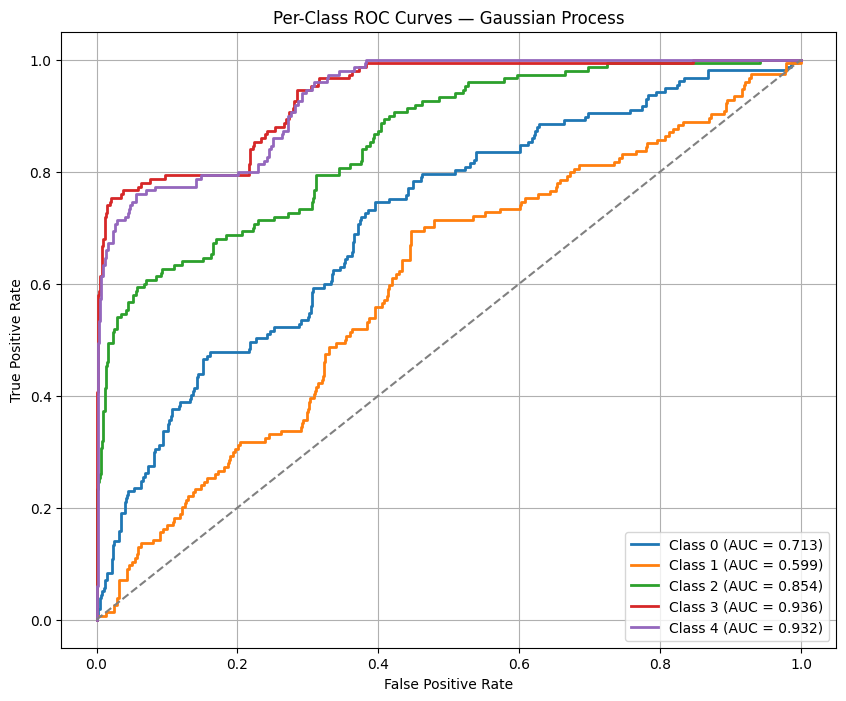

{'Logistic Regression': {'accuracy': 0.4704336399474376,
  'roc_auc': 0.7425447836874237,
  'mean_uncertainty': np.float64(1.2147805781101817)},
 'KNN': {'accuracy': 0.580814717477004,
  'roc_auc': 0.834489677100384,
  'mean_uncertainty': np.float64(0.8186117664266674)},
 'Random Forest': {'accuracy': 0.6491458607095927,
  'roc_auc': 0.879439938444051,
  'mean_uncertainty': np.float64(1.2233803439721314)},
 'XGBoost': {'accuracy': 0.6544021024967148,
  'roc_auc': 0.8772582296383005,
  'mean_uncertainty': np.float64(0.7942658582538288)},
 'Gaussian Process': {'accuracy': 0.533508541392904,
  'roc_auc': 0.8067550250601411,
  'mean_uncertainty': np.float64(1.4401163652833062)}}

In [4]:
#  Multiclass evaluation

evaluate_models_cv_with_tuning(
    X_resampled,
    y_resampled,
    "Multiclass ISUP 1–5 (SMOTE k=3)"
)
